# EDA — Diabetes Prediction Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, chi2_contingency
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

## 1. Chargement et description générale

In [2]:
df = pd.read_csv('../data/diabetes_prediction_dataset.csv')
print(f'Nombre de lignes     : {df.shape[0]}')
print(f'Nombre de colonnes   : {df.shape[1]}')
print(f'\nTypes de variables :')
print(df.dtypes)
print(f'\nApercu des 10 premieres lignes :')
display(df.head(10))

Nombre de lignes     : 100000
Nombre de colonnes   : 9

Types de variables :
gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Apercu des 10 premieres lignes :


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


## 2. Valeurs manquantes

In [3]:
missing = pd.DataFrame({
    'Variable':        df.columns,
    'Manquantes':      df.isnull().sum().values,
    'Pourcentage (%)': (df.isnull().sum().values / len(df) * 100).round(2)
})
display(missing)
print(f'\nTotal valeurs manquantes : {df.isnull().sum().sum()}')

,Variable,Manquantes,Pourcentage (%)
0,gender,0,0.0
1,age,0,0.0
2,hypertension,0,0.0
3,heart_disease,0,0.0
4,smoking_history,0,0.0
5,bmi,0,0.0
6,HbA1c_level,0,0.0
7,blood_glucose_level,0,0.0
8,diabetes,0,0.0



Total valeurs manquantes : 0


## 3. Statistiques descriptives

In [4]:
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
cat_cols = ['gender', 'smoking_history']
bin_cols = ['hypertension', 'heart_disease']

print('=== Variables numeriques ===')
display(df[num_cols].describe().round(3))

print('\n=== Variables categorielles ===')
for col in cat_cols:
    print(f'\n{col} :')
    vc  = df[col].value_counts()
    pct = df[col].value_counts(normalize=True) * 100
    display(pd.DataFrame({'Count': vc, 'Pourcentage (%)': pct.round(2)}))

print('\n=== Variables binaires ===')
for col in bin_cols:
    vc  = df[col].value_counts()
    pct = df[col].value_counts(normalize=True) * 100
    print(f'\n{col} :')
    display(pd.DataFrame({'Count': vc, 'Pourcentage (%)': pct.round(2)}))

=== Variables numeriques ===


,age,bmi,HbA1c_level,blood_glucose_level
count,100000.000,100000.000,100000.000,100000.000
mean,41.886,27.321,5.528,138.058
std,22.517,6.637,1.071,40.708
min,0.080,10.010,3.500,80.000
25%,24.000,23.630,4.800,100.000
50%,43.000,27.320,5.800,140.000
75%,60.000,29.580,6.200,159.000
max,80.000,95.690,9.000,300.000



=== Variables categorielles ===

gender :


,Count,Pourcentage (%)
gender,,
Female,58552,58.55
Male,41430,41.43
Other,18,0.02



smoking_history :


,Count,Pourcentage (%)
smoking_history,,
No Info,35816,35.82
never,35095,35.10
former,9352,9.35
current,9286,9.29
not current,6447,6.45
ever,4004,4.00



=== Variables binaires ===

hypertension :


,Count,Pourcentage (%)
hypertension,,
0,92515,92.52
1,7485,7.48



heart_disease :


,Count,Pourcentage (%)
heart_disease,,
0,96058,96.06
1,3942,3.94


## 4. Distribution de la variable cible

Classe 0 (Non-diabetique) : 91500 (91.50%)
Classe 1 (Diabetique)     : 8500 (8.50%)
Ratio desequilibre        : 1 pour 10


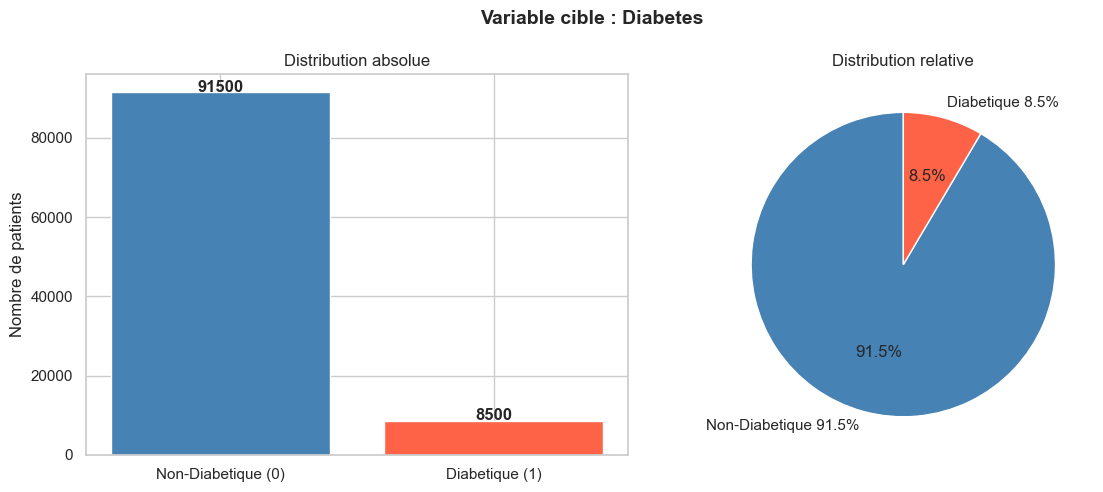

In [5]:
counts = df['diabetes'].value_counts()
pcts   = df['diabetes'].value_counts(normalize=True) * 100

print(f'Classe 0 (Non-diabetique) : {counts[0]} ({pcts[0]:.2f}%)')
print(f'Classe 1 (Diabetique)     : {counts[1]} ({pcts[1]:.2f}%)')
print(f'Ratio desequilibre        : 1 pour {counts[0]//counts[1]}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Non-Diabetique (0)', 'Diabetique (1)'],
            [counts[0], counts[1]],
            color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Distribution absolue')
axes[0].set_ylabel('Nombre de patients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values,
            labels=[f'Non-Diabetique {pcts[0]:.1f}%', f'Diabetique {pcts[1]:.1f}%'],
            colors=['steelblue', 'tomato'],
            startangle=90, autopct='%1.1f%%')
axes[1].set_title('Distribution relative')

plt.suptitle('Variable cible : Diabetes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Distributions variables numériques + Skewness

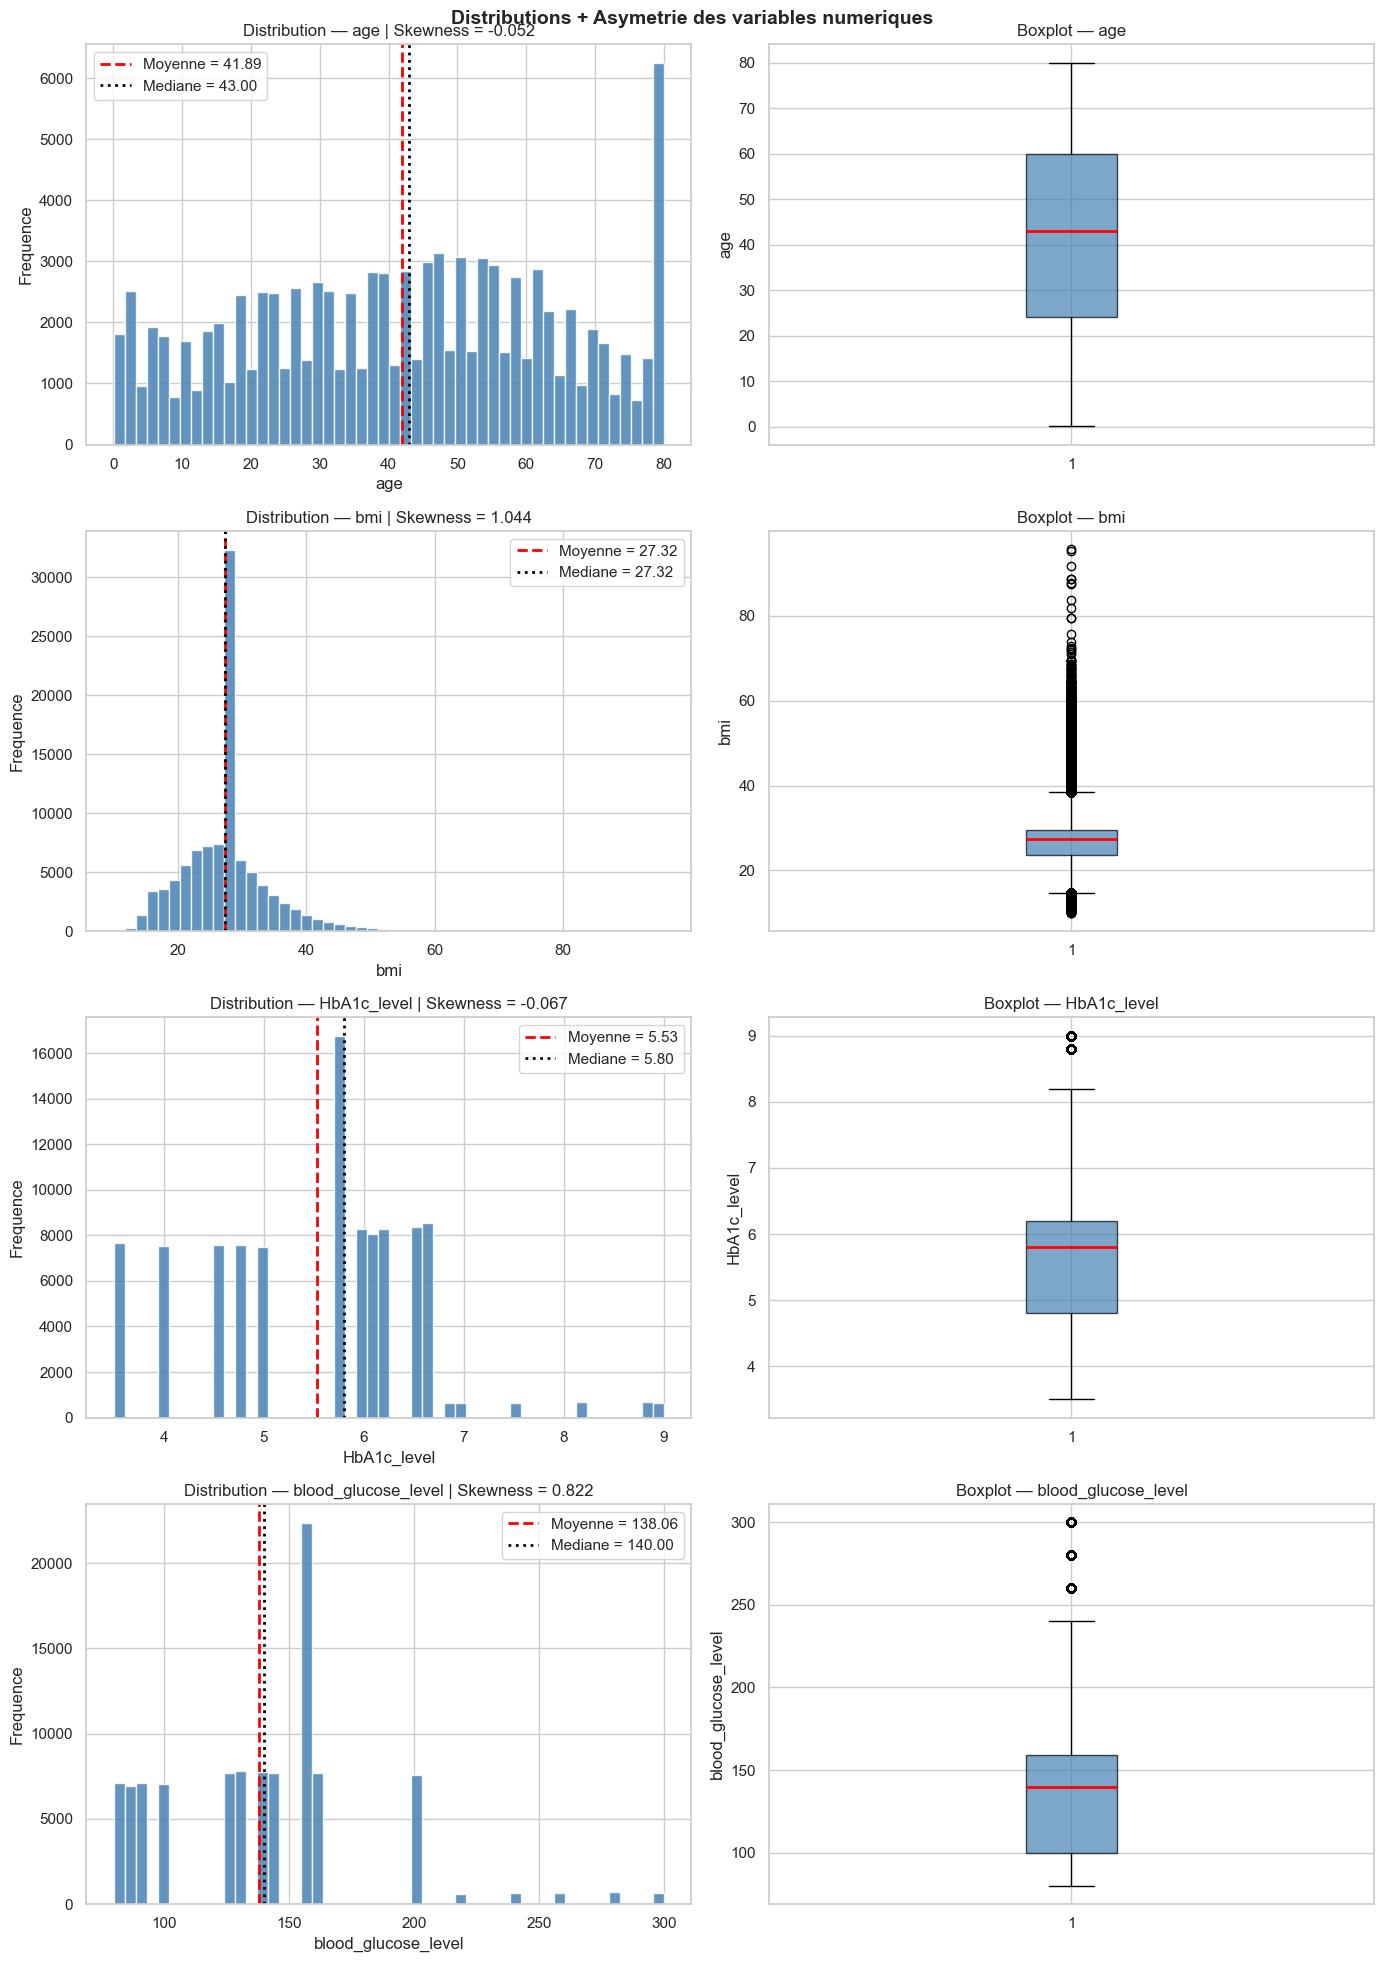


Skewness (> 1 ou < -1 = asymetrie forte) :
  age                       : -0.052  -> Symetrique
  bmi                       : 1.044  -> Asymetrie forte
  HbA1c_level               : -0.067  -> Symetrique
  blood_glucose_level       : 0.822  -> Asymetrie moderee


In [6]:
fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, 5 * len(num_cols)))

for i, col in enumerate(num_cols):
    sk = df[col].skew()
    axes[i, 0].hist(df[col], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i, 0].axvline(df[col].mean(),   color='red',   linestyle='--', linewidth=2,
                       label=f'Moyenne = {df[col].mean():.2f}')
    axes[i, 0].axvline(df[col].median(), color='black', linestyle=':',  linewidth=2,
                       label=f'Mediane = {df[col].median():.2f}')
    axes[i, 0].set_title(f'Distribution — {col} | Skewness = {sk:.3f}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequence')
    axes[i, 0].legend()
    axes[i, 1].boxplot(df[col], patch_artist=True,
                       boxprops=dict(facecolor='steelblue', alpha=0.7),
                       medianprops=dict(color='red', linewidth=2))
    axes[i, 1].set_title(f'Boxplot — {col}')
    axes[i, 1].set_ylabel(col)

plt.suptitle('Distributions + Asymetrie des variables numeriques', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nSkewness (> 1 ou < -1 = asymetrie forte) :')
for col in num_cols:
    sk = df[col].skew()
    niveau = 'Asymetrie forte' if abs(sk) > 1 else ('Asymetrie moderee' if abs(sk) > 0.5 else 'Symetrique')
    print(f'  {col:<25} : {sk:.3f}  -> {niveau}')

## 6. Détection des outliers (IQR)

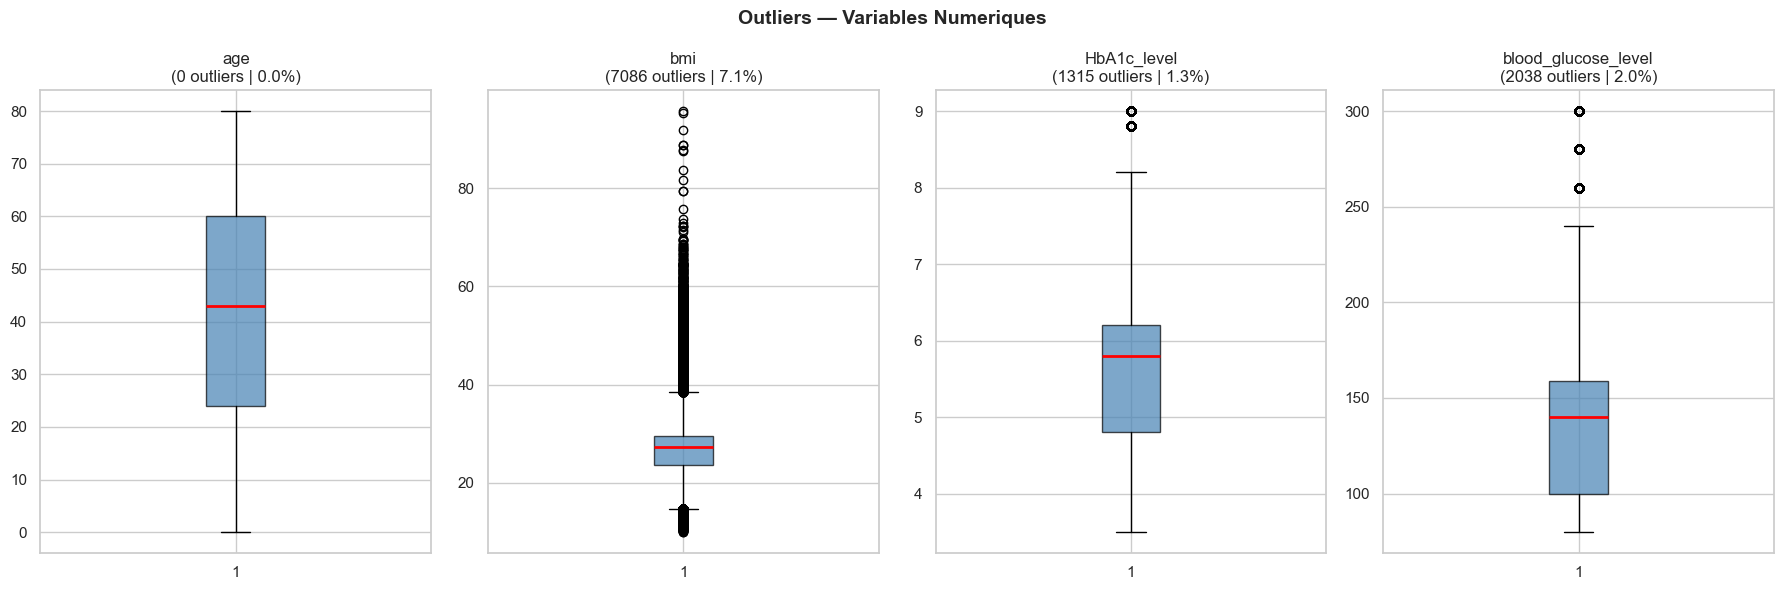

,Variable,Borne inf,Borne sup,Nb outliers,% dataset,Taux diabete outliers (%),Taux diabete normaux (%)
0,age,-30.0,114.0,0,0.00,0.0,8.5
1,bmi,14.7,38.5,7086,7.09,20.9,7.6
2,HbA1c_level,2.7,8.3,1315,1.32,100.0,7.3
3,blood_glucose_level,11.5,247.5,2038,2.04,100.0,6.6


In [7]:
outlier_results = []
fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 6))

for i, col in enumerate(num_cols):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lb  = Q1 - 1.5 * IQR
    ub  = Q3 + 1.5 * IQR
    mask_out = (df[col] < lb) | (df[col] > ub)
    n   = mask_out.sum()
    taux_out    = df[mask_out]['diabetes'].mean() * 100 if n > 0 else 0
    taux_normal = df[~mask_out]['diabetes'].mean() * 100
    outlier_results.append({
        'Variable':                   col,
        'Borne inf':                  round(lb, 2),
        'Borne sup':                  round(ub, 2),
        'Nb outliers':                n,
        '% dataset':                  round(n / len(df) * 100, 2),
        'Taux diabete outliers (%)':  round(taux_out, 1),
        'Taux diabete normaux (%)':   round(taux_normal, 1)
    })
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{col}\n({n} outliers | {n/len(df)*100:.1f}%)')

plt.suptitle('Outliers — Variables Numeriques', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
display(pd.DataFrame(outlier_results))

## 7. Analyse critique des outliers

In [8]:
# BMI
print('--- BMI ---')
Q1_b  = df['bmi'].quantile(0.25)
Q3_b  = df['bmi'].quantile(0.75)
ub_b  = Q3_b + 1.5*(Q3_b - Q1_b)
out_b = df[df['bmi'] > ub_b]
print(f'Min={df["bmi"].min():.2f} | Max={df["bmi"].max():.2f}')
print(f'Taux diabete outliers BMI : {out_b["diabetes"].mean()*100:.1f}%')
print(f'Taux diabete normaux  BMI : {df[~df.index.isin(out_b.index)]["diabetes"].mean()*100:.1f}%')

# HbA1c
print('\n--- HbA1c_level ---')
Q1_h  = df['HbA1c_level'].quantile(0.25)
Q3_h  = df['HbA1c_level'].quantile(0.75)
ub_h  = Q3_h + 1.5*(Q3_h - Q1_h)
out_h = df[df['HbA1c_level'] > ub_h]
print(f'Seuil IQR sup : {ub_h:.2f}')
print(f'Nb outliers   : {len(out_h)}')
print(f'Taux diabete outliers HbA1c : {out_h["diabetes"].mean()*100:.1f}%')
print('-> HbA1c eleve = marqueur clinique du diabete')

# blood_glucose
print('\n--- blood_glucose_level ---')
Q1_g  = df['blood_glucose_level'].quantile(0.25)
Q3_g  = df['blood_glucose_level'].quantile(0.75)
ub_g  = Q3_g + 1.5*(Q3_g - Q1_g)
out_g = df[df['blood_glucose_level'] > ub_g]
print(f'Seuil IQR sup : {ub_g:.2f}')
print(f'Nb outliers   : {len(out_g)}')
print(f'Taux diabete outliers glucose : {out_g["diabetes"].mean()*100:.1f}%')
print('-> Glycemie elevee = marqueur clinique du diabete')

# Age
print('\n--- age ---')
age_inf = df[df['age'] < 1]
print(f'Patients age < 1 an : {len(age_inf)}')
print(f'Taux diabete < 1 an : {age_inf["diabetes"].mean()*100:.1f}%')
display(age_inf[['age','diabetes']].head(10))

--- BMI ---
Min=10.01 | Max=95.69
Taux diabete outliers BMI : 24.6%
Taux diabete normaux  BMI : 7.5%

--- HbA1c_level ---
Seuil IQR sup : 8.30
Nb outliers   : 1315
Taux diabete outliers HbA1c : 100.0%
-> HbA1c eleve = marqueur clinique du diabete

--- blood_glucose_level ---
Seuil IQR sup : 247.50
Nb outliers   : 2038
Taux diabete outliers glucose : 100.0%
-> Glycemie elevee = marqueur clinique du diabete

--- age ---
Patients age < 1 an : 911
Taux diabete < 1 an : 0.0%


,age,diabetes
155,0.08,0
218,0.56,0
241,0.88,0
268,0.16,0
396,0.16,0
480,0.64,0
577,0.72,0
578,0.72,0
677,0.88,0
792,0.80,0


## 8. Décision sur les outliers

In [9]:
decisions = [
    ('HbA1c_level',         'CONSERVER — marqueur clinique, 100% diabetiques'),
    ('blood_glucose_level', 'CONSERVER — marqueur clinique, 100% diabetiques'),
    ('bmi',                 'CONSERVER — lie medicalement au diabete (obesite)'),
    ('age < 1 an',          'CONSERVER — anomalie notee, aucun diabetique dans ce groupe'),
]

print(f'{"Variable":<25} {"Decision"}')
print('-' * 75)
for var, dec in decisions:
    print(f'{var:<25} {dec}')

print('\nCONCLUSION :')
print('-> Aucun outlier supprime.')
print('-> Valeurs medicalement justifiees ou porteuses d information sur la cible.')
print('-> Supprimer ferait perdre de l information diagnostique.')

df_clean = df.copy()
print(f'\nDataset conserve : {df_clean.shape[0]} lignes')

Variable                  Decision
---------------------------------------------------------------------------
HbA1c_level               CONSERVER — marqueur clinique, 100% diabetiques
blood_glucose_level       CONSERVER — marqueur clinique, 100% diabetiques
bmi                       CONSERVER — lie medicalement au diabete (obesite)
age < 1 an                CONSERVER — anomalie notee, aucun diabetique dans ce groupe

CONCLUSION :
-> Aucun outlier supprime.
-> Valeurs medicalement justifiees ou porteuses d information sur la cible.
-> Supprimer ferait perdre de l information diagnostique.

Dataset conserve : 100000 lignes


## 9. Boxplots par statut diabétique

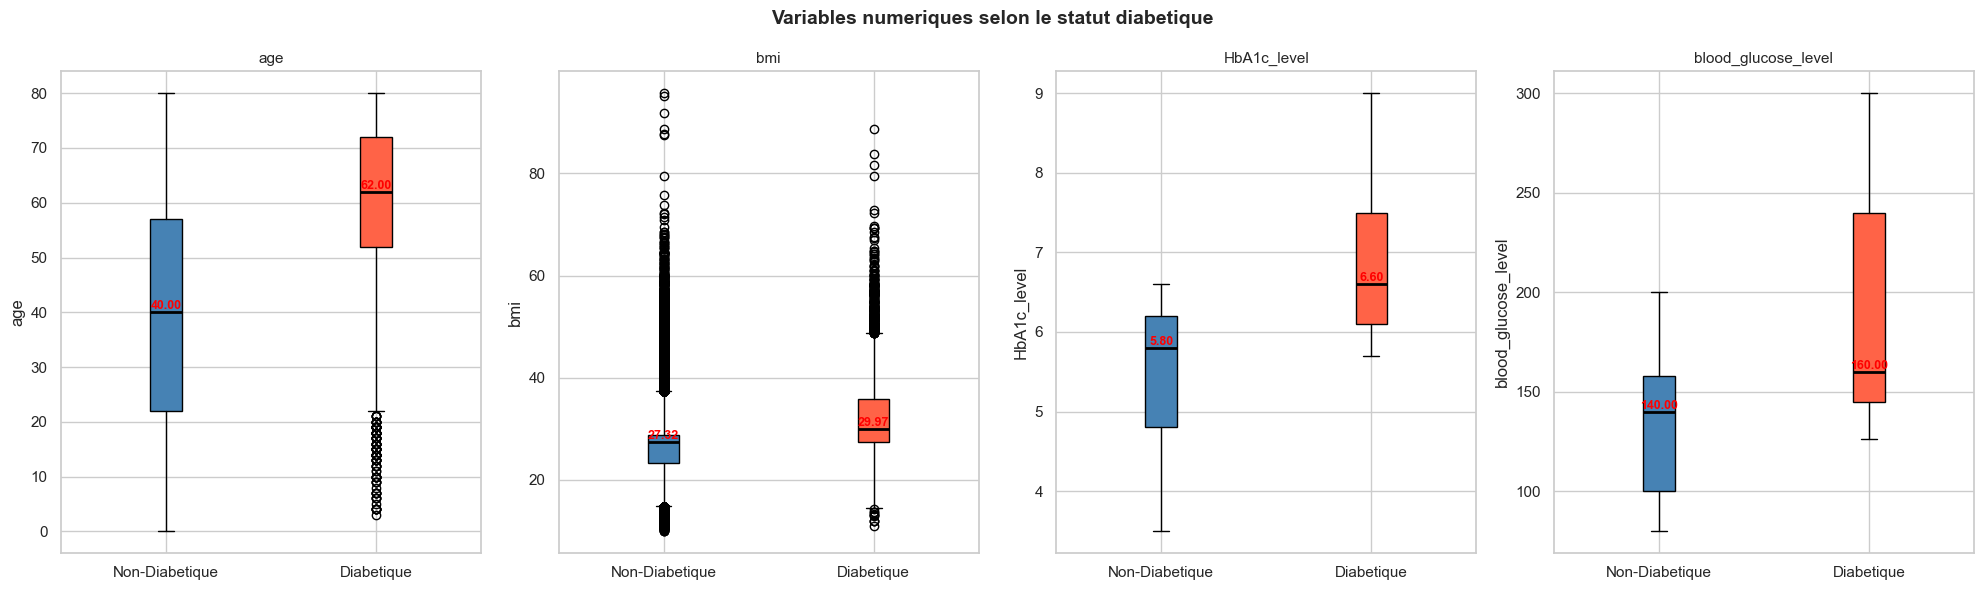


Moyennes par groupe (0=Non-diabetique, 1=Diabetique) :


,age,bmi,HbA1c_level,blood_glucose_level,hypertension,heart_disease
diabetes,,,,,,
0,40.115,26.887,5.397,132.852,0.059,0.029
1,60.947,31.988,6.935,194.095,0.246,0.149


In [10]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 6))

for i, col in enumerate(num_cols):
    data_0 = df[df['diabetes'] == 0][col]
    data_1 = df[df['diabetes'] == 1][col]
    bp = axes[i].boxplot([data_0, data_1],
                          labels=['Non-Diabetique', 'Diabetique'],
                          patch_artist=True,
                          medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('tomato')
    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].set_ylabel(col)
    for j, data in enumerate([data_0, data_1]):
        axes[i].text(j+1, data.median(), f'{data.median():.2f}',
                     ha='center', va='bottom', fontweight='bold', fontsize=9, color='red')

plt.suptitle('Variables numeriques selon le statut diabetique', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nMoyennes par groupe (0=Non-diabetique, 1=Diabetique) :')
display(df.groupby('diabetes')[num_cols + bin_cols].mean().round(3))

## 10. Variables catégorielles vs Diabetes

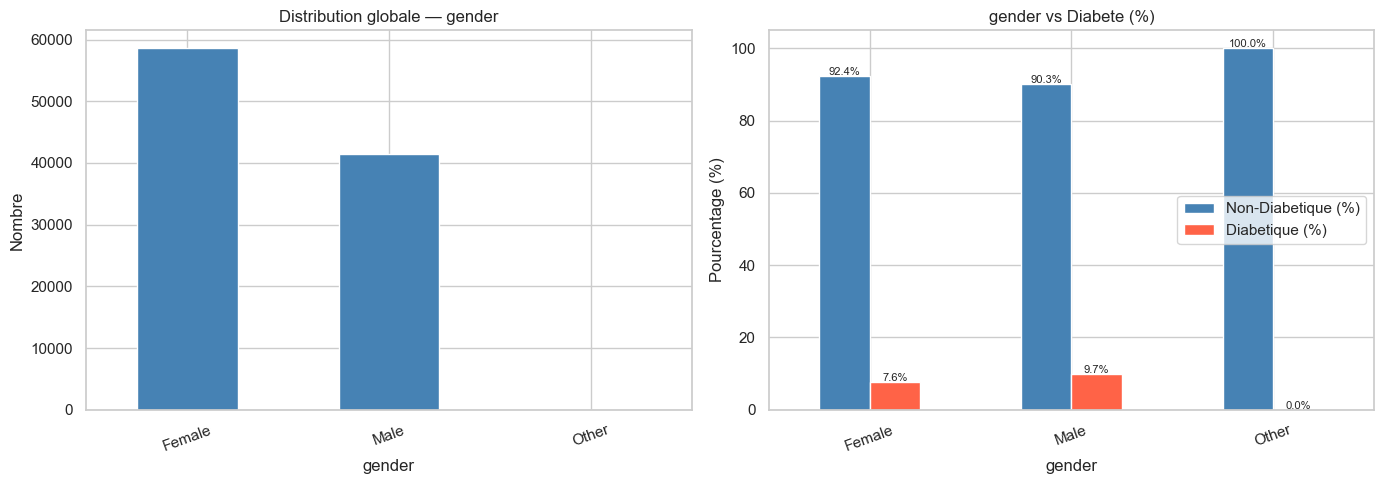

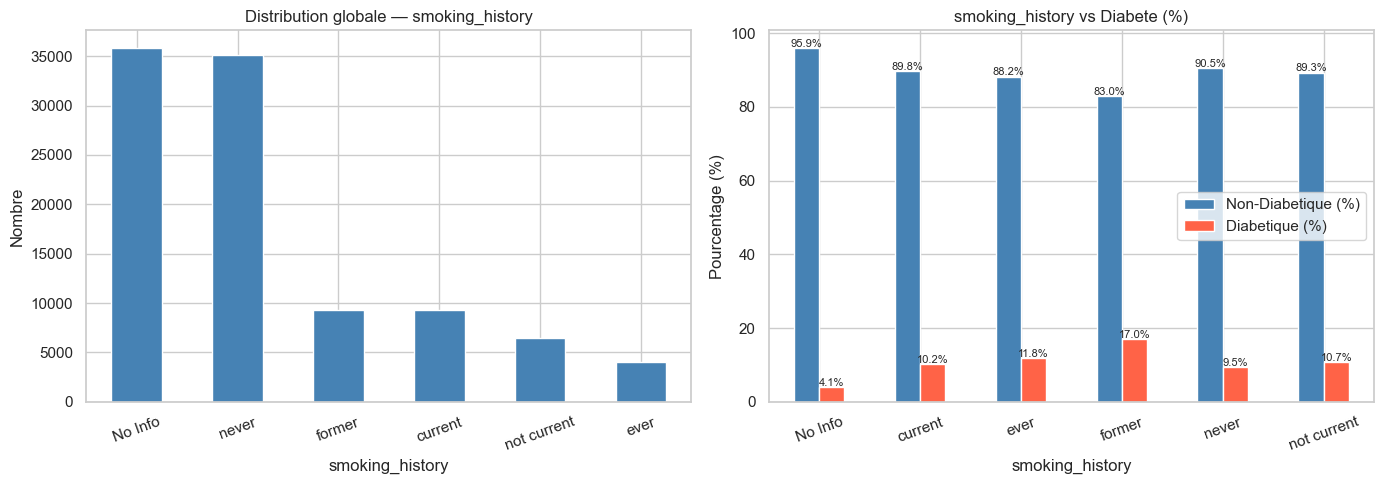

In [11]:
for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    df[col].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
    axes[0].set_title(f'Distribution globale — {col}')
    axes[0].tick_params(axis='x', rotation=20)
    axes[0].set_ylabel('Nombre')
    ct = pd.crosstab(df[col], df['diabetes'], normalize='index') * 100
    ct.columns = ['Non-Diabetique (%)', 'Diabetique (%)']
    ct.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='white')
    axes[1].set_title(f'{col} vs Diabete (%)')
    axes[1].tick_params(axis='x', rotation=20)
    axes[1].set_ylabel('Pourcentage (%)')
    for bar in axes[1].patches:
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.3,
                     f'{bar.get_height():.1f}%', ha='center', fontsize=8)
    plt.tight_layout()
    plt.show()

## 11. Variables binaires vs Diabetes

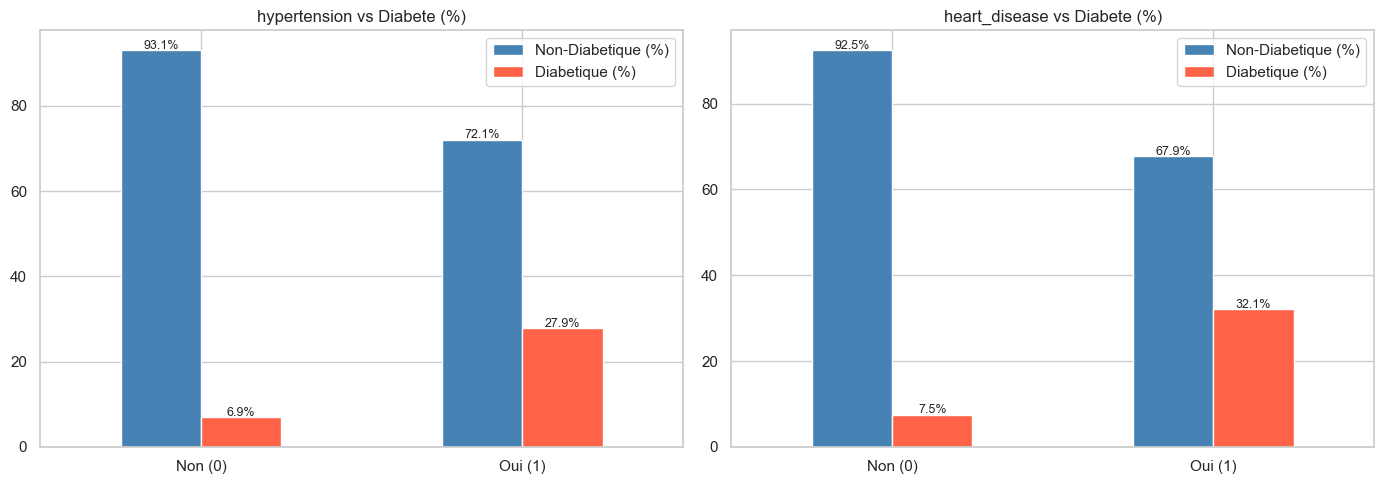


Taux de diabete selon hypertension :
hypertension
0     6.93
1    27.90
Name: diabetes, dtype: float64

Taux de diabete selon heart_disease :
heart_disease
0     7.53
1    32.14
Name: diabetes, dtype: float64


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, col in enumerate(bin_cols):
    ct = pd.crosstab(df[col], df['diabetes'], normalize='index') * 100
    ct.index = ['Non (0)', 'Oui (1)']
    ct.columns = ['Non-Diabetique (%)', 'Diabetique (%)']
    ct.plot(kind='bar', ax=axes[i], color=['steelblue', 'tomato'], edgecolor='white')
    axes[i].set_title(f'{col} vs Diabete (%)')
    axes[i].tick_params(axis='x', rotation=0)
    for bar in axes[i].patches:
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.3,
                     f'{bar.get_height():.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

for col in bin_cols:
    taux = df.groupby(col)['diabetes'].mean() * 100
    print(f'\nTaux de diabete selon {col} :')
    print(taux.round(2))

## 12. Matrice de corrélation

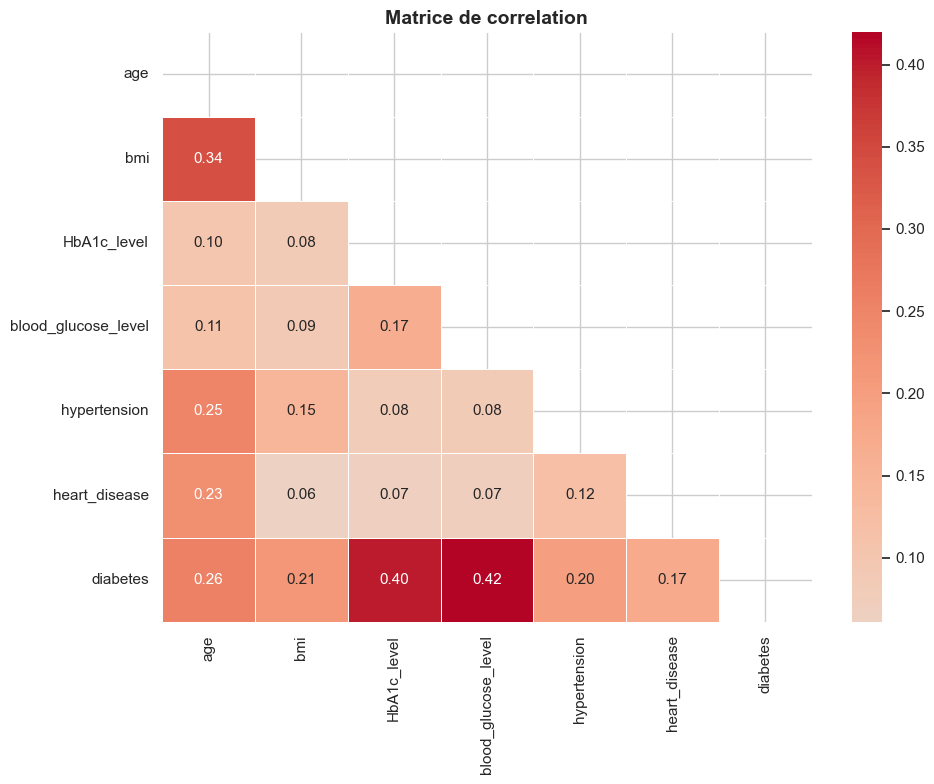


Correlations avec diabetes (triees) :


,diabetes
blood_glucose_level,0.4196
HbA1c_level,0.4007
age,0.2580
bmi,0.2144
hypertension,0.1978
heart_disease,0.1717


In [13]:
corr_cols = num_cols + bin_cols + ['diabetes']
corr      = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, linewidths=0.5,
            annot_kws={'size': 11})
plt.title('Matrice de correlation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelations avec diabetes (triees) :')
display(corr['diabetes'].drop('diabetes').sort_values(ascending=False).to_frame().round(4))

## 13. Tests statistiques (ANOVA + Chi²)

In [14]:
print('=' * 65)
print('ANOVA : Variables numeriques -> diabetes')
print('=' * 65)
print(f"{'Variable':<25} {'F-stat':<14} {'p-value':<14} {'Resultat'}")
print('-' * 65)

for col in num_cols:
    g0 = df[df['diabetes'] == 0][col]
    g1 = df[df['diabetes'] == 1][col]
    f, p = f_oneway(g0, g1)
    res = 'Significatif' if p < 0.05 else 'Non significatif'
    print(f'{col:<25} {f:<14.2f} {p:<14.6f} {res}')

print('\n' + '=' * 65)
print('Chi2 : Variables categorielles + binaires -> diabetes')
print('=' * 65)
print(f"{'Variable':<25} {'Chi2':<14} {'p-value':<14} {'Resultat'}")
print('-' * 65)

for col in cat_cols + bin_cols:
    ct = pd.crosstab(df[col], df['diabetes'])
    chi2, p, _, _ = chi2_contingency(ct)
    res = 'Significatif' if p < 0.05 else 'Non significatif'
    print(f'{col:<25} {chi2:<14.2f} {p:<14.6f} {res}')

ANOVA : Variables numeriques -> diabetes
Variable                  F-stat         p-value        Resultat
-----------------------------------------------------------------
age                       7131.41        0.000000       Significatif
bmi                       4816.11        0.000000       Significatif
HbA1c_level               19122.21       0.000000       Significatif
blood_glucose_level       21363.05       0.000000       Significatif

Chi2 : Variables categorielles + binaires -> diabetes
Variable                  Chi2           p-value        Resultat
-----------------------------------------------------------------
gender                    143.22         0.000000       Significatif
smoking_history           1956.09        0.000000       Significatif
hypertension              3910.71        0.000000       Significatif
heart_disease             2945.85        0.000000       Significatif


## 14. Analyse par tranche d'âge

,age_group,nb_patients,nb_diabetiques,taux_%
0,0-18,18400,92,0.50
1,19-30,15333,209,1.36
2,31-45,20144,913,4.53
3,46-60,22491,2567,11.41
4,61-80,23632,4719,19.97


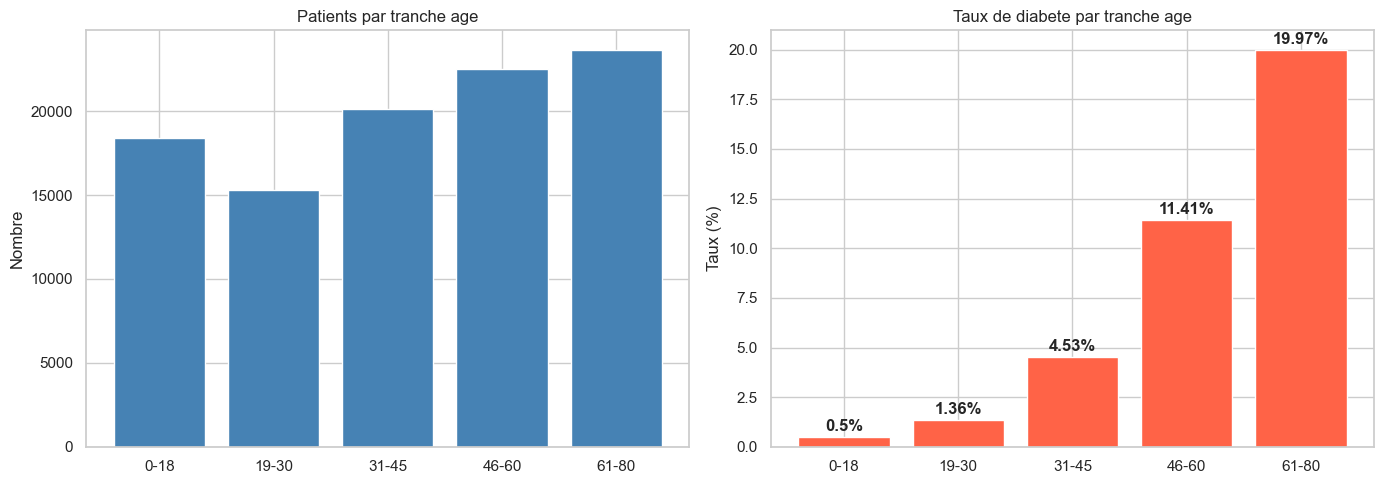

In [15]:
bins_age = [0, 18, 30, 45, 60, 80]
labels_age = ['0-18', '19-30', '31-45', '46-60', '61-80']
df['age_group'] = pd.cut(df['age'], bins=bins_age, labels=labels_age)

age_stats = df.groupby('age_group', observed=True).agg(
    nb_patients    = ('diabetes', 'count'),
    nb_diabetiques = ('diabetes', 'sum'),
    taux_diabete   = ('diabetes', 'mean')
).reset_index()
age_stats['taux_%'] = (age_stats['taux_diabete'] * 100).round(2)
display(age_stats.drop(columns='taux_diabete'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(age_stats['age_group'].astype(str), age_stats['nb_patients'],
            color='steelblue', edgecolor='white')
axes[0].set_title('Patients par tranche age')
axes[0].set_ylabel('Nombre')

axes[1].bar(age_stats['age_group'].astype(str), age_stats['taux_%'],
            color='tomato', edgecolor='white')
axes[1].set_title('Taux de diabete par tranche age')
axes[1].set_ylabel('Taux (%)')
for i, v in enumerate(age_stats['taux_%']):
    axes[1].text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 15. Conclusions EDA

In [16]:
print('=' * 65)
print('CONCLUSIONS EDA')
print('=' * 65)
print(f'\n1. Dataset       : {df.shape[0]} patients, {df.shape[1]} variables')
print(f'   Valeurs manquantes : {df.isnull().sum().sum()}')
print(f'\n2. Desequilibre  : {df["diabetes"].mean()*100:.1f}% diabetiques')
print( '   -> A gerer dans le preprocessing (class_weight)')
print( '\n3. Outliers      : Tous conserves (medicalement justifies)')
print( '\n4. Correlations avec diabetes :')
display(corr['diabetes'].drop('diabetes').sort_values(ascending=False).to_frame().round(4))
print( '\n5. Dataset pret pour preprocessing et modelisation.')

CONCLUSIONS EDA

1. Dataset       : 100000 patients, 10 variables
   Valeurs manquantes : 0

2. Desequilibre  : 8.5% diabetiques
   -> A gerer dans le preprocessing (class_weight)

3. Outliers      : Tous conserves (medicalement justifies)

4. Correlations avec diabetes :


,diabetes
blood_glucose_level,0.4196
HbA1c_level,0.4007
age,0.2580
bmi,0.2144
hypertension,0.1978
heart_disease,0.1717



5. Dataset pret pour preprocessing et modelisation.
